In [1]:
import util
import matplotlib.pyplot as plt
import nd2
import PIL
import skimage as ski
import numpy as np


In [2]:
stack_paths = ["data/mNeoG-vP1_GFP_500ms_50%_Cy3_1s_50%_1006.nd2"]
mask_paths = ["data/Celldetection_1.tif"]

In [3]:
all_stacks = [np.moveaxis(nd2.imread(path), 0, -1)/2.0**16 for path in stack_paths]
all_masks = [np.asarray(PIL.Image.open(path), dtype=np.bool) for path in mask_paths]

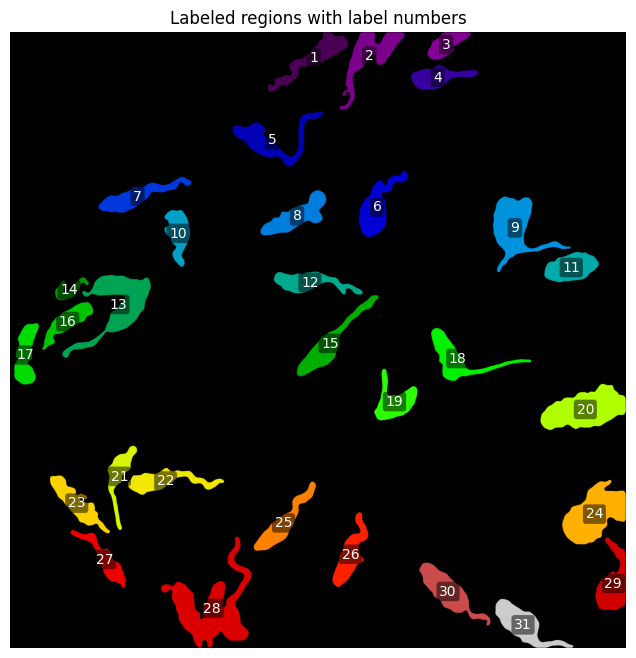

In [4]:
all_labels: np.ndarray = [ski.measure.label(mask) for mask in all_masks] # type: ignore
for labels in all_labels:
    util.plot_labels(labels)

In [5]:


extracted_stacks = []
extracted_masks = [] 
for stack, labels in zip(all_stacks, all_labels):
    extracted_stack, extracted_mask = util.extract_stacks(stack, labels)
    extracted_stacks += extracted_stack
    extracted_masks += extracted_mask

In [6]:
accepted_stacks = util.filter_stacks(extracted_stacks, extracted_masks)

In [10]:
print(accepted_stacks)
accepted_stacks = [0, 3, 5, 6, 7, 9, 10, 11, 14, 15, 17, 18, 21, 22, 24, 25, 29]

[]


In [11]:
stacks = [util.normalize_stack(extracted_stacks[i][...,1:]) for i in accepted_stacks]
masks = [extracted_masks[i] for i in accepted_stacks]

Manders overlap
$$\frac{\sum A_i B_i}{\sqrt{\sum A_i^2 \sum B_i^2}}$$

In [12]:
THRESHOLD_AB = 0.5
THRESHOLD_BA = 0.5

moc_coeffs = util.manders_overlap_coeff(stacks, masks, ch1=1, ch2=2, threshold_ab=THRESHOLD_AB, threshold_ba=THRESHOLD_BA)
pearson_coeffs = util.pearson_corr_coeff(stacks, masks, ch1=1, ch2=2)

mean_moc = np.mean(moc_coeffs, axis=0)
std_moc = np.std(moc_coeffs, axis=0)
mean_pearson = np.mean(pearson_coeffs)
std_pearson = np.std(pearson_coeffs)

descriptions = ["MOC", "M1", "M2"]
for (desc, mean, std) in zip(descriptions,mean_moc, std_moc):
    print(f"{desc}: {mean:.4f} ± {std:.4f}")
print(f"Pearson: {mean_pearson:.4f} ± {std_pearson:.4f}")


MOC: 0.8741 ± 0.0833
M1: 0.2977 ± 0.2374
M2: 0.4635 ± 0.2165
Pearson: 0.7435 ± 0.1160


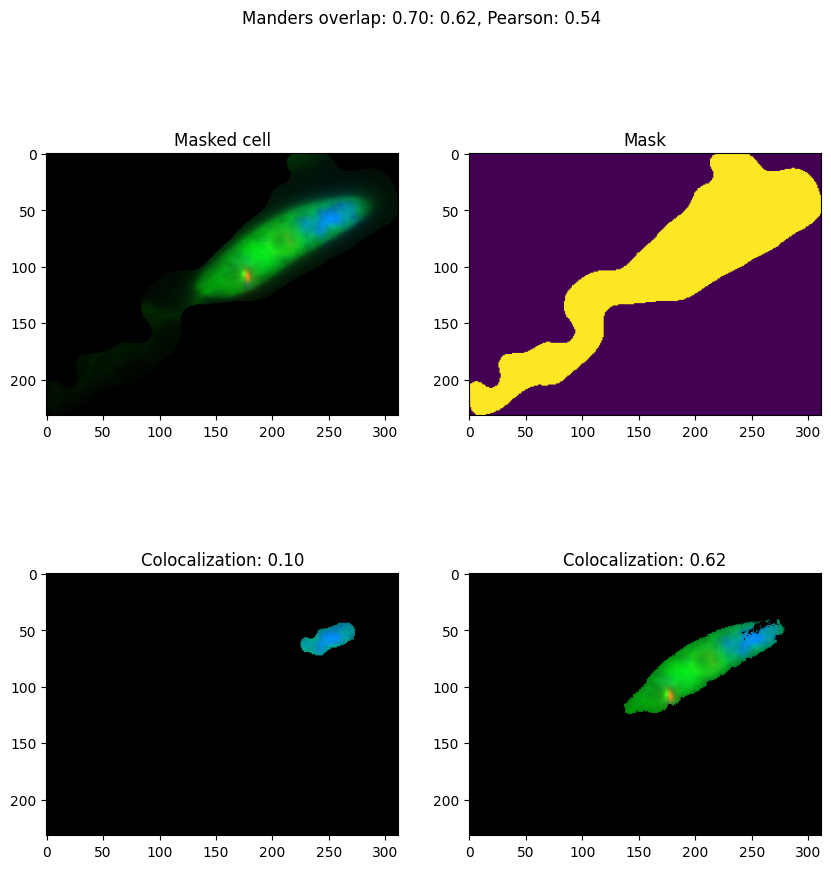

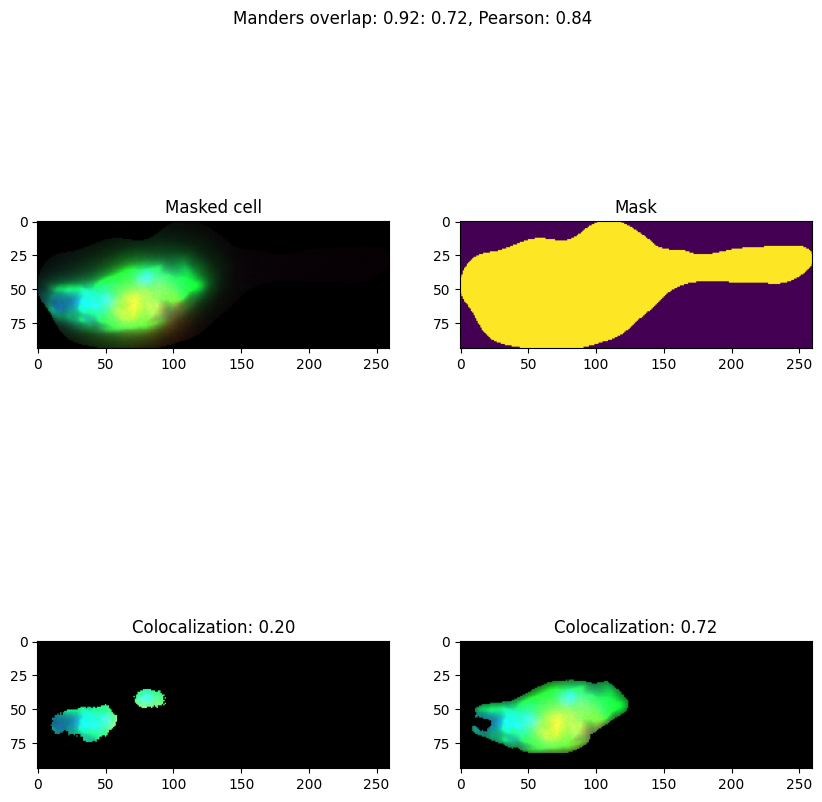

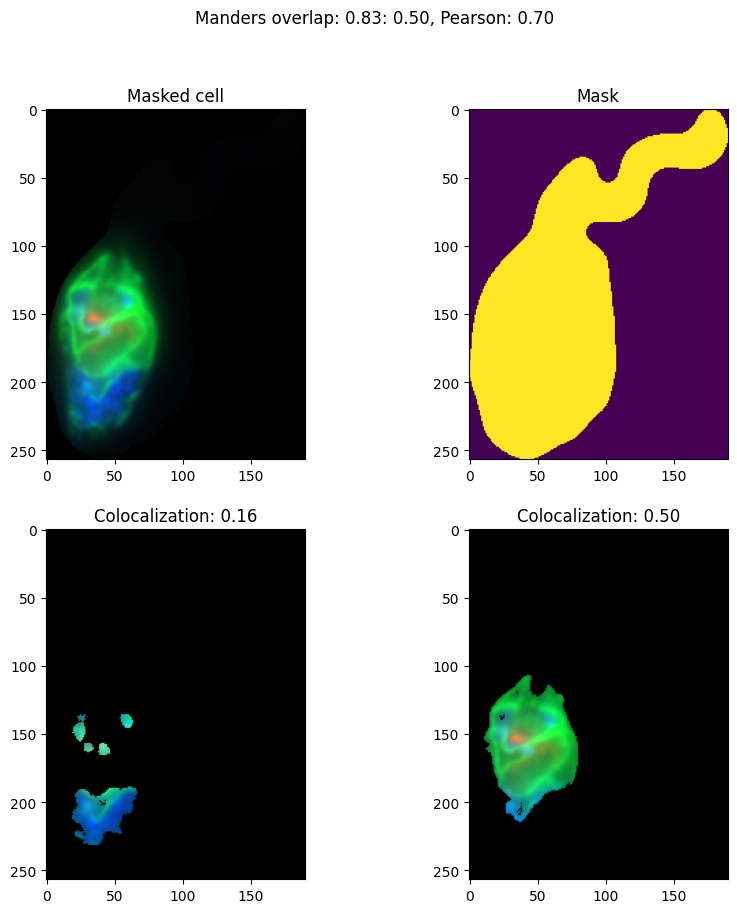

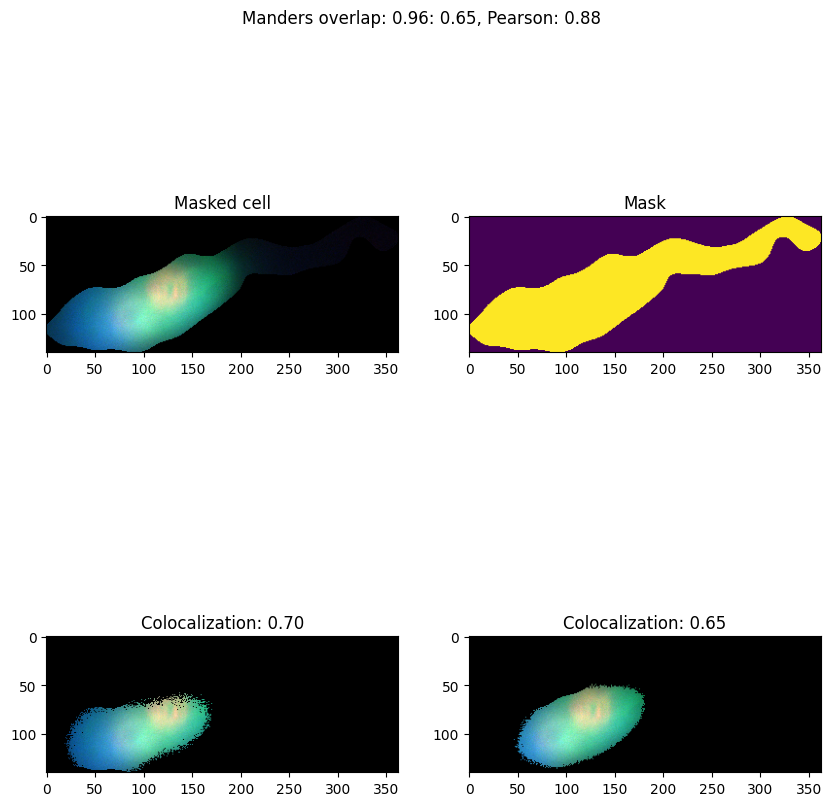

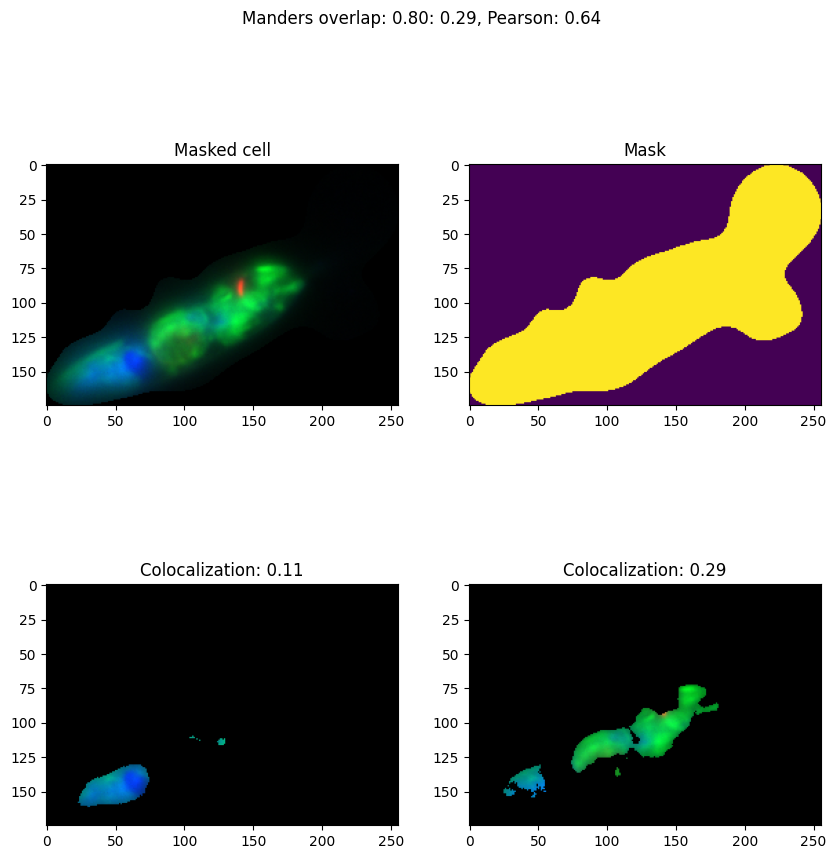

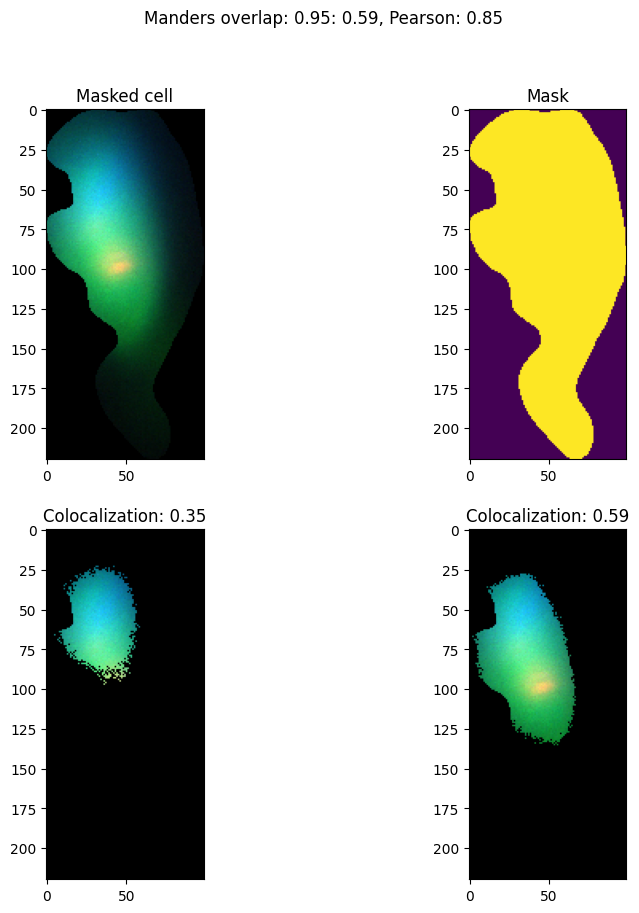

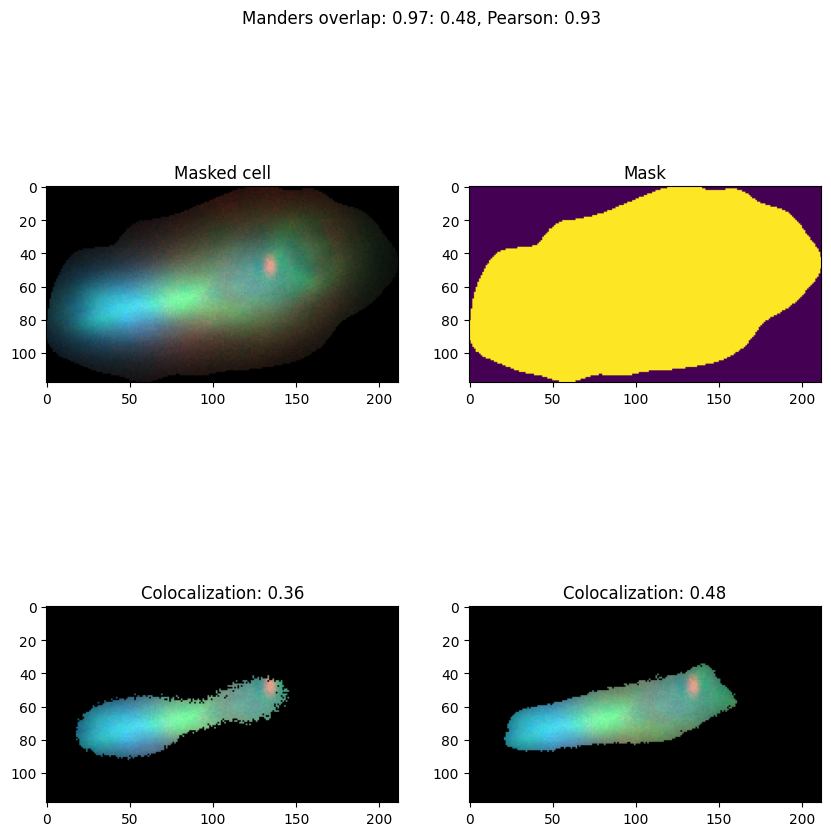

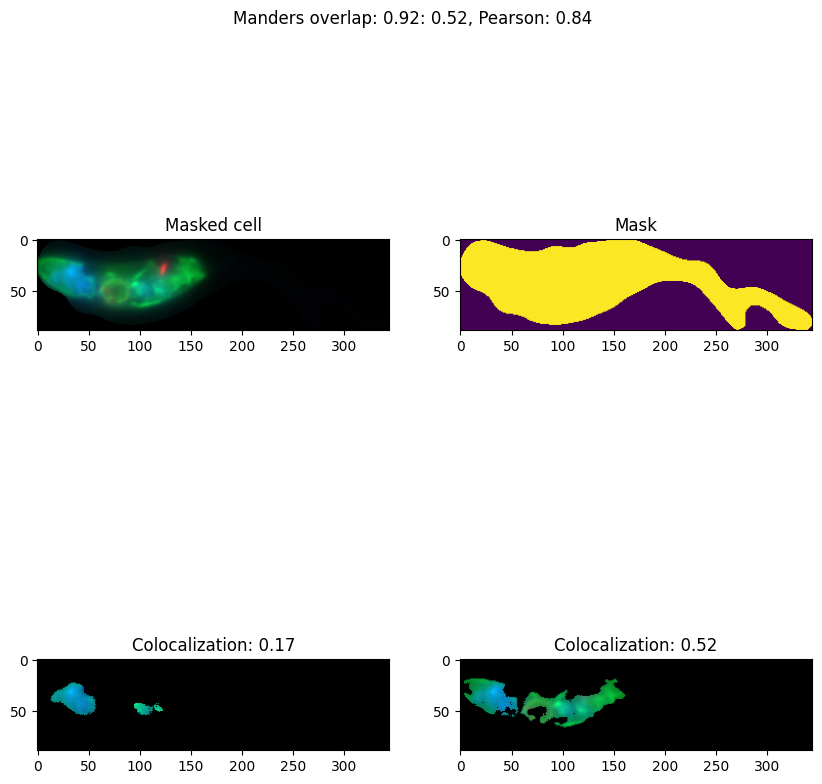

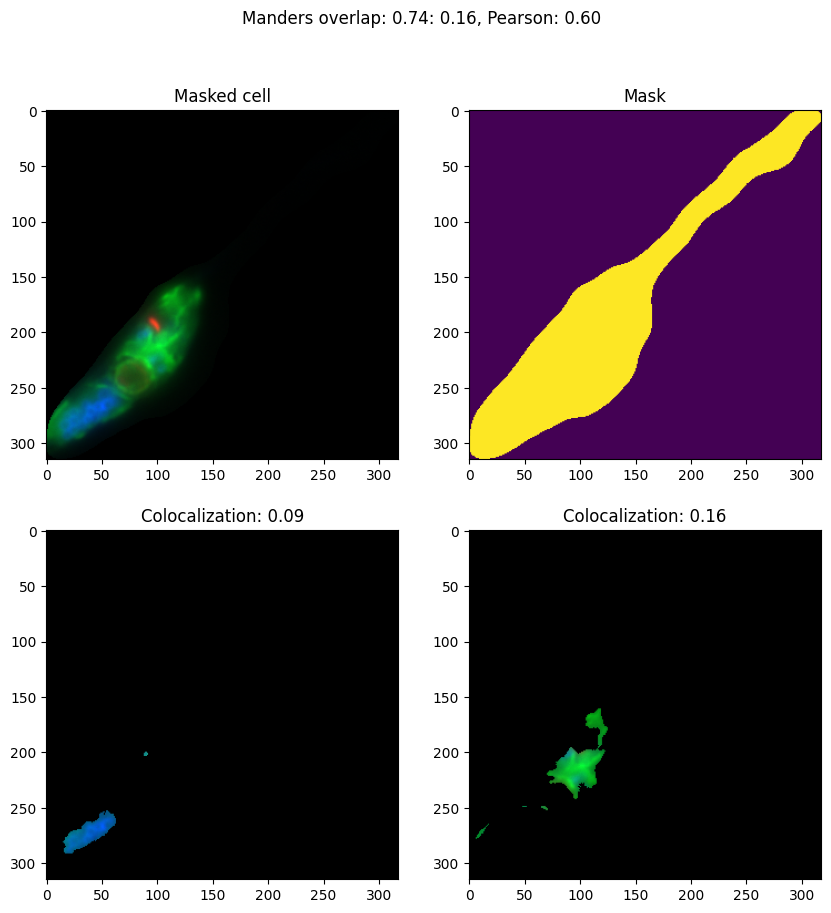

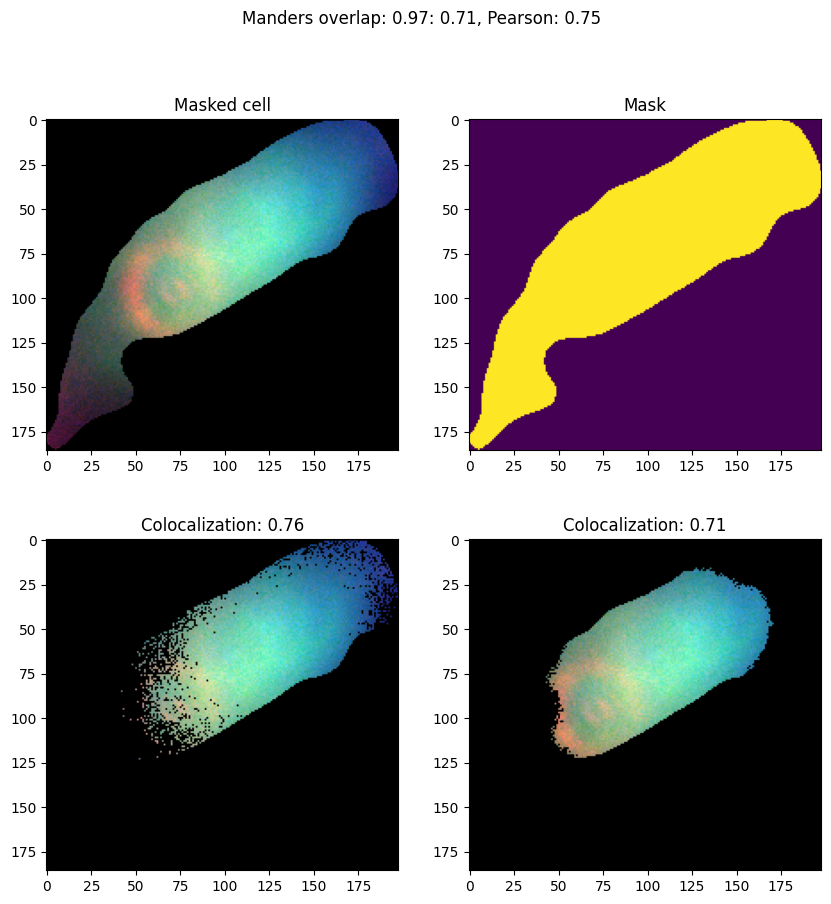

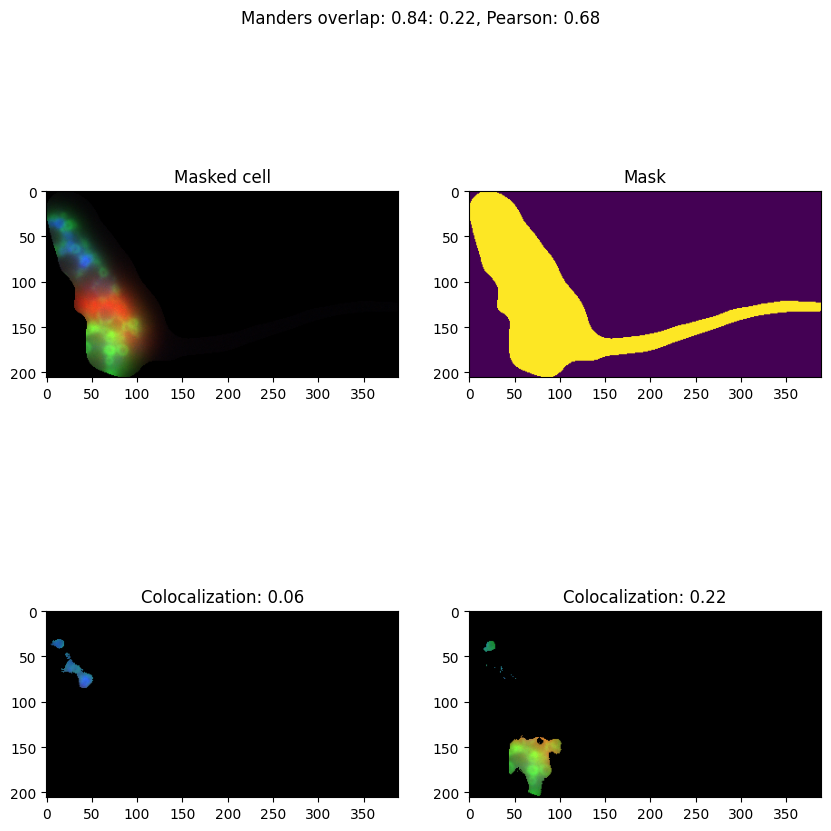

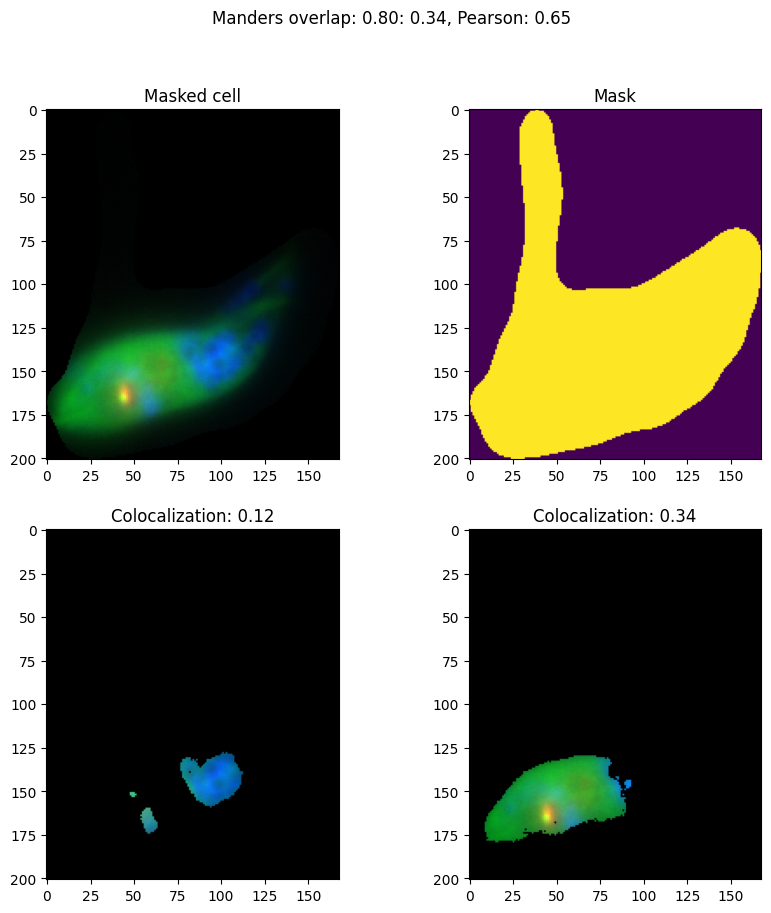

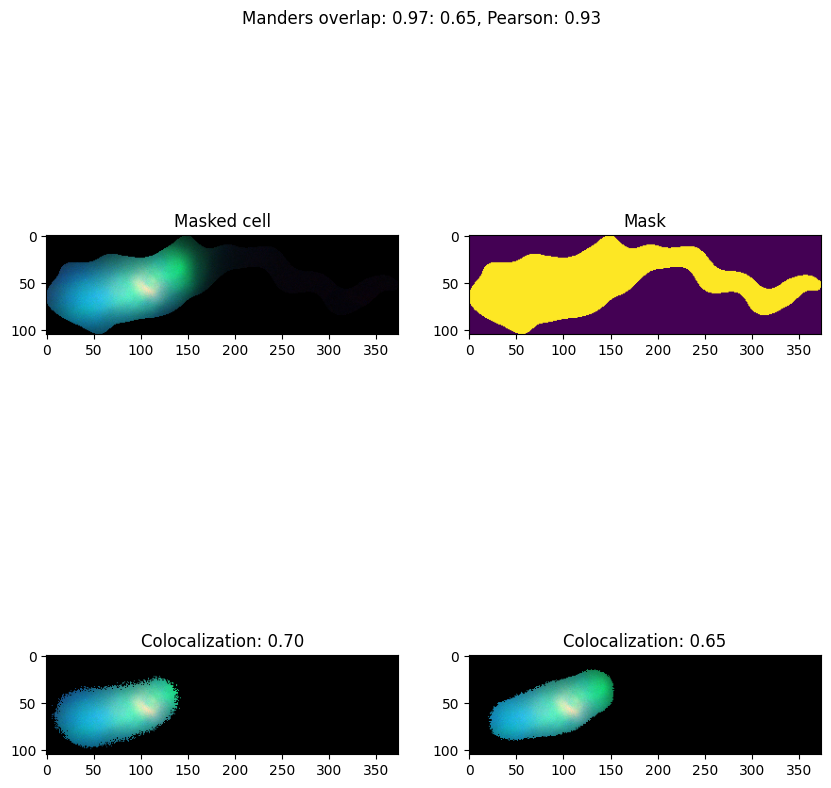

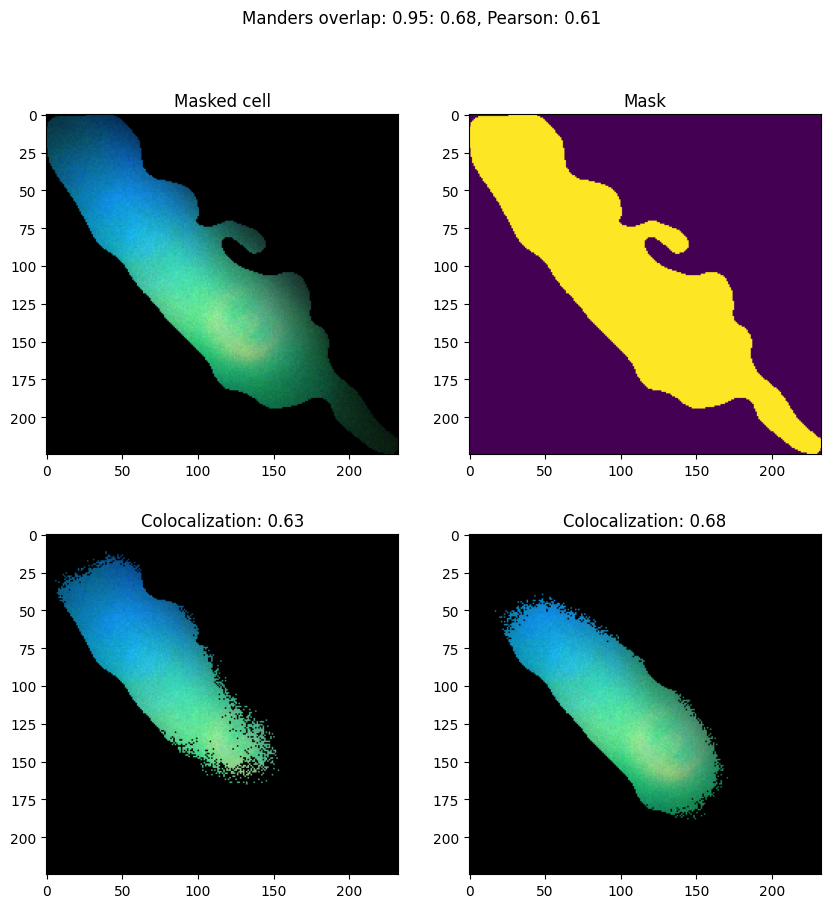

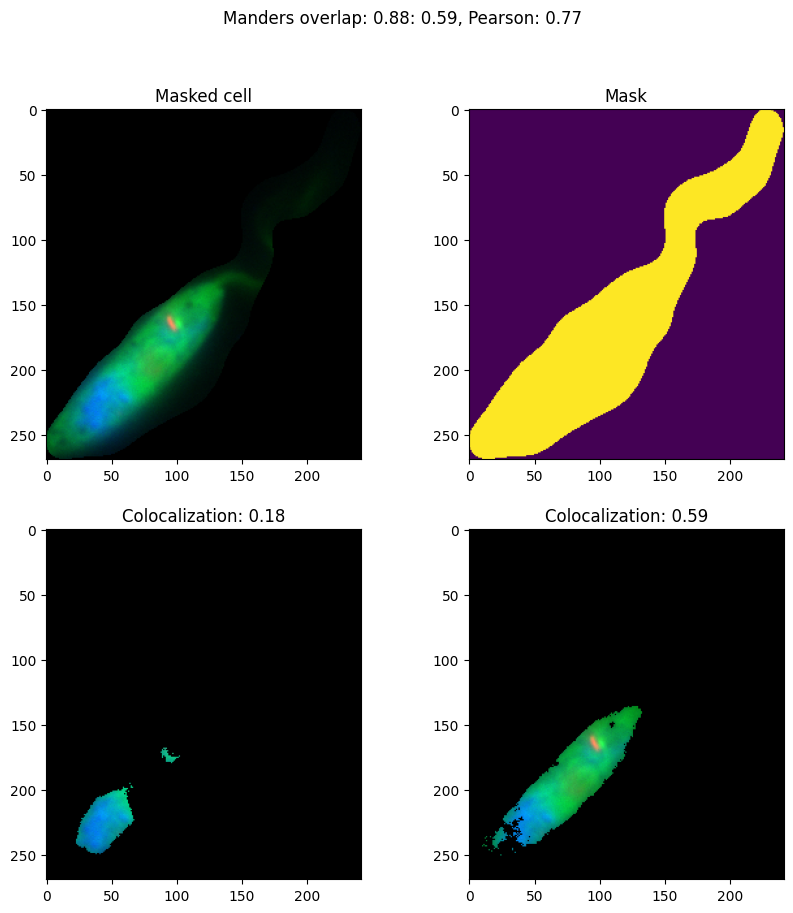

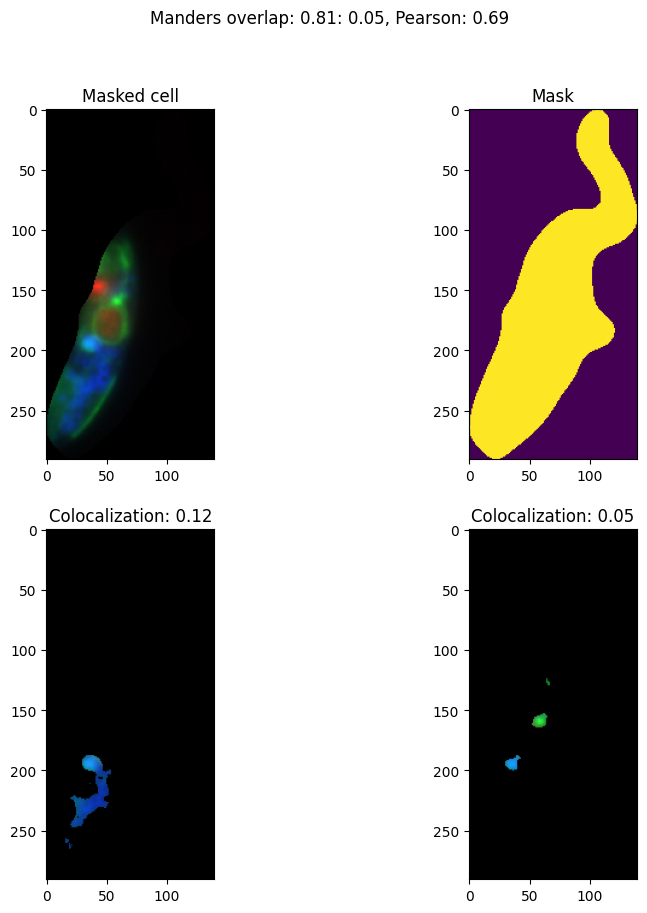

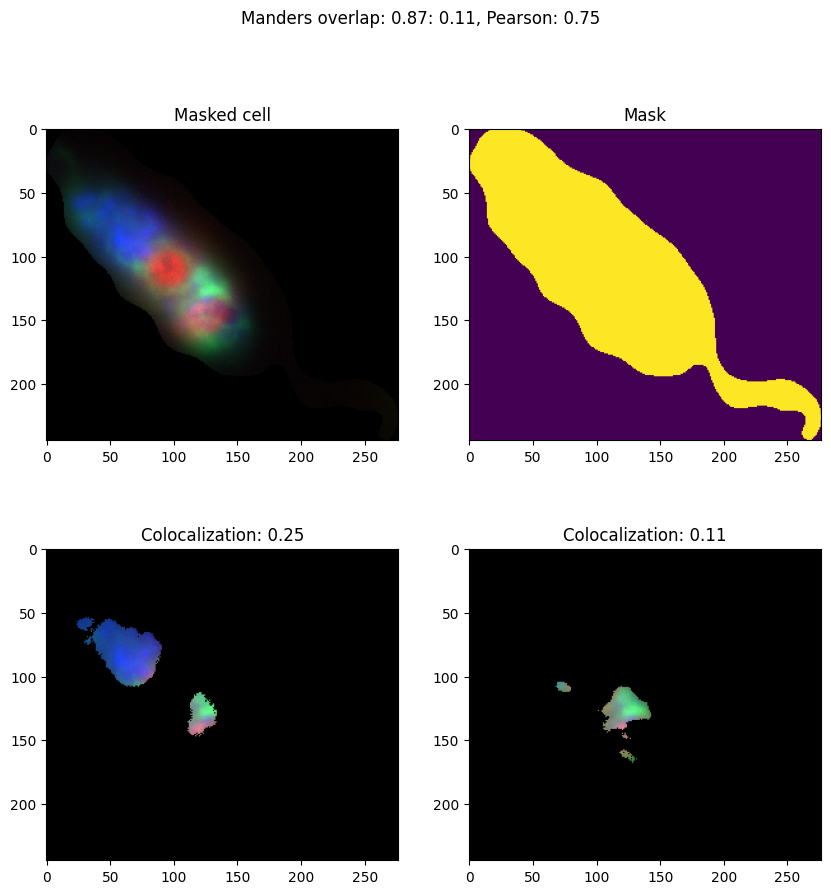

In [13]:
for i, stack, mask, [moc, moc_ab, moc_ba], pearson in zip(accepted_stacks, stacks, masks, moc_coeffs, pearson_coeffs):
    masked_stack = stack*mask[...,None]
    plt.subplots(2, 2, figsize=(10,10))
    plt.suptitle(f"Manders overlap: {moc:.2f}: {moc_ba:.2f}, Pearson: {pearson:.2f}")
    plt.subplot(2,2,1)
    plt.title(f"Masked cell")
    plt.imshow(masked_stack)
    plt.subplot(2,2,2)
    plt.title(f"Mask")
    plt.imshow(mask)
    plt.subplot(2,2,3)
    plt.title(f"Colocalization: {moc_ab:.2f}")
    plt.imshow(masked_stack*(stack[...,2]>THRESHOLD_AB)[...,None])
    plt.subplot(2,2,4)
    plt.title(f"Colocalization: {moc_ba:.2f}")
    plt.imshow(masked_stack*(stack[...,1]>THRESHOLD_BA)[...,None])
    plt.show()